In [1]:
from google.colab import drive
drive.mount('/content/drive')
# rust
!unzip "/content/drive/MyDrive/Corrosion_Data/rust.zip" -d "/content/rust"

# no_rust
!unzip "/content/drive/MyDrive/Corrosion_Data/no_rust.zip" -d "/content/no_rust"


Mounted at /content/drive
Archive:  /content/drive/MyDrive/Corrosion_Data/rust.zip
 extracting: /content/rust/001_w1nojjln.bdv.jpg  
 extracting: /content/rust/002_cql5orz2.p0y.jpg  
 extracting: /content/rust/002_q40jac40.sd4.jpg  
 extracting: /content/rust/003_glbjresp.01k.jpg  
 extracting: /content/rust/004_1xgwoahx.lqq.jpg  
 extracting: /content/rust/004_i1dmciub.oop.jpg  
 extracting: /content/rust/004_liem2hdg.3w2.jpg  
 extracting: /content/rust/004_uouhxp2m.0ax.jpg  
 extracting: /content/rust/004_z3jrhz45.3ms.jpg  
 extracting: /content/rust/005_txq3nygx.w0v.jpg  
Archive:  /content/drive/MyDrive/Corrosion_Data/no_rust.zip
 extracting: /content/no_rust/001_0fwtaowy.t1o.jpg  
 extracting: /content/no_rust/001_kwmsqgk2.yfv.jpg  
 extracting: /content/no_rust/002_2bvturws.zss.jpg  
 extracting: /content/no_rust/002_dr3selb3.a1h.jpg  
 extracting: /content/no_rust/002_mjcgc4b1.ru0.jpg  
 extracting: /content/no_rust/002_ocpp5ini.zep.jpg  
 extracting: /content/no_rust/002_vzt4z

In [4]:
!pip install numpy matplotlib scikit-learn seaborn tensorflow
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Data Preparation

In [5]:
def count_images_in_directory(directory):
  """
  Utility function to count images in a given directory
  :param directory: The directory to count images in
  :return: None
  """
  total_count = 0
  for root, dirs, files in os.walk(directory):
    file_count = len(files)
    print(f"{root}: {file_count} images")
    total_count += file_count


In [19]:
import os
import shutil

# Create the 'Training' and 'Validation' folders
os.makedirs('Training', exist_ok=True)

# Move folders into Training
try:
    if os.path.exists('rust'):
        shutil.move('rust', 'Training/rust')
    if os.path.exists('no_rust'):
        shutil.move('no_rust', 'Training/no_rust')
    print("✅ Folders moved to Training/ successfully!")
except Exception as e:
    print(f"Note: {e} (Folders might already be moved)")

# Rename 'test_set' to 'Validation'
if os.path.exists('test_set'):
    os.rename('test_set', 'Validation')
    print("Renamed test_set to Validation!")

✅ Folders moved to Training/ successfully!


In [25]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set BASE_PATH to your current Colab directory
BASE_PATH = '/content'

def data_preparation():
    """
    Prepare the data for training and testing
    :return: train_dir, test_dir
    """
    # Use the exact folder names you have in your Colab sidebar
    target_classes = ['rust', 'norust']

    # Define where the split data will be stored
    # We will create a new folder named 'corrosion_data' to keep it clean
    processed_path = os.path.join(BASE_PATH, 'corrosion_data')
    train_dir = os.path.join(processed_path, 'train')
    test_dir = os.path.join(processed_path, 'test')

    # Create directories if they don't exist
    if not os.path.exists(train_dir):
        os.makedirs(train_dir)
    if not os.path.exists(test_dir):
        os.makedirs(test_dir)

    for c in target_classes:
        # Create class folders inside train and test
        os.makedirs(os.path.join(train_dir, c), exist_ok=True)
        os.makedirs(os.path.join(test_dir, c), exist_ok=True)

        # Point to your raw images (extracted from zip)
        # The folders 'rust' and 'no_rust' were moved to 'Training/rust' and 'Training/no_rust' by a previous cell.
        # The kernel state shows 'norust' is the folder name under 'Training'.
        labeled_dir = os.path.join(BASE_PATH, 'Training', c)

        # Get list of all image files
        images = []
        for file in os.listdir(labeled_dir):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images.append(os.path.join(labeled_dir, file))

        # Split 20% of images for testing (2 images per class if total is 10)
        # This ensures both train and test sets are non-empty.
        train_images, test_images = train_test_split(images, test_size=0.2, random_state=1)

        # Copy images to the new structured folders
        for image in train_images:
            shutil.copy(image, os.path.join(train_dir, c))
        for image in test_images:
            shutil.copy(image, os.path.join(test_dir, c))

        print(f"Class {c}: Total {len(images)} images. Moved {len(test_images)} to Test and {len(train_images)} to Train.")

    return train_dir, test_dir

# Execute the function
train_path, test_path = data_preparation()

Class rust: Total 10 images. Moved 2 to Test and 8 to Train.
Class norust: Total 10 images. Moved 2 to Test and 8 to Train.


In [26]:
print("Starting data preparation process...")
train_dir, test_dir = data_preparation()
count_images_in_directory(train_dir)
count_images_in_directory(test_dir)
print("Data preparation completed.")

Starting data preparation process...
Class rust: Total 10 images. Moved 2 to Test and 8 to Train.
Class norust: Total 10 images. Moved 2 to Test and 8 to Train.
/content/corrosion_data/train: 0 images
/content/corrosion_data/train/norust: 8 images
/content/corrosion_data/train/rust: 8 images
/content/corrosion_data/test: 0 images
/content/corrosion_data/test/norust: 2 images
/content/corrosion_data/test/rust: 2 images
Data preparation completed.


CNN model

In [27]:
def plot_accuracy(history, model_name):
  """
  Function to plot the accuracy of the model
  :param history: The history of the model
  :param model_name: The name of the model
  :return: None
  """
  plt.title(f"{model_name} accuracy")
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

In [28]:
def show_true_and_predicted_classes(model, test_generator):
  """
  Shows the true and predicted classes for the given model and test generator.
  :param model: The trained Keras model.
  :param test_generator: The test data generator.
  :return: None
  """

  # Get the true labels and predicted labels
  y_true = test_generator.classes
  y_pred = model.predict(test_generator).argmax(axis=1)
  filenames = test_generator.filenames

  # Print the true and predicted labels for each sample
  print("True and Predicted Classes:")
  for i in range(len(y_true)):
    print(f"Image {filenames[i]}: True = {y_true[i]}, Predicted = {y_pred[i]}")

  # Create a confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # Plot the confusion matrix using seaborn
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=test_generator.class_indices,
              yticklabels=test_generator.class_indices)
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.show()

In [29]:
from tensorflow.keras.utils import save_img

def save_predicted_images(model, test_generator, dir_to_save):
  """
  Function to save the predicted images
  :param model: The model to use
  :param test_generator: The test generator
  :param dir_to_save: The directory to save the images
  :return: None
  """
  if not os.path.exists(dir_to_save):
    os.makedirs(dir_to_save)
  classes = list(test_generator.class_indices.keys())
  for batches_idx, (imgs, labels) in enumerate(test_generator):
    preds = model.predict(imgs)
    filenames = test_generator.filenames[batches_idx * test_generator.batch_size : (batches_idx + 1) * test_generator.batch_size]
    pred_class_indices = np.argmax(preds, axis=1)
    for i in range(imgs.shape[0]):
      img = imgs[i]
      pred_class_label = classes[pred_class_indices[i]]
      orig_filename = os.path.basename(filenames[i])
      path_to_save = os.path.join(dir_to_save, f"{os.path.splitext(orig_filename)[0]}_{pred_class_label}.png")
      save_img(path_to_save, img)
    if batches_idx == len(test_generator) -1:
      break

In [30]:
def with_basic_cnn(train_dir, test_dir):
  """
  Function to build, train and test the basic CNN model
  :param train_dir: The directory of the training data
  :param test_dir: The directory of the testing data
  :return: model_builder
  """
  # Define target image's width and height
  image_width, image_height = 32, 32
  # Create a sequential builder to build the model
  model_builder = Sequential([
    Input(shape=(image_width, image_height, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
  ])
  model_builder.summary()
  # Compile with adam and categorical crossentropy
  model_builder.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  # Convert train and test dataset using ImageDataGenerator
  train_datagen = ImageDataGenerator(rescale=1./255)
  test_datagen = ImageDataGenerator(rescale=1./255)
  train_generator = train_datagen.flow_from_directory(train_dir, target_size=(image_width, image_height), batch_size=32, class_mode='categorical')
  test_generator = test_datagen.flow_from_directory(test_dir, target_size=(image_width, image_height), batch_size=32, class_mode='categorical')
  # Fith with 20 epochs (100 steps per epoch)
  history = model_builder.fit(train_generator, epochs=20, steps_per_epoch=100, validation_data=test_generator, validation_steps=50)
  # Plot the accuracy
  plot_accuracy(history, "Basic CNN")
  show_true_and_predicted_classes(model_builder, test_generator)
  # Eval and save predicted images to the folder
  print(f"Test accuracy of Basic CNN: {model_builder.evaluate(test_generator)[1] * 100:.2f}%")
  print(f"Saving Predicted CNN to {BASE_PATH}/cnn_test")
  save_predicted_images(model_builder, test_generator, BASE_PATH + "/cnn_test")
  return model_builder

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,170 (621.76 KB)

 Trainable params: 159,170 (621.76 KB)

 Non-trainable params: 0 (0.00 B)

Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/20
  1/100 ━━━━━━━━━━━━━━━━━━━━ 4:29 3s/step - accuracy: 0.4375 - loss: 0.6937

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4375 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.7094
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.5000 - loss: 0.6772 - val_accuracy: 0.5000 - val_loss: 0.7005
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.5000 - loss: 0.6611 - val_accuracy: 0.5000 - val_loss: 0.6855
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.6875 - loss: 0.6495 - val_accuracy: 0.5000 - val_loss: 0.6822
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.6875 - loss: 0.6278 - val_accuracy: 0.5000 - val_loss: 0.6884
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.6250 - loss: 0.6039 - val_accuracy: 0.5000 - val_loss: 0.6760
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - accuracy: 0.6875 - loss: 0.5752 - val_accuracy: 0.7500 - val_loss: 0.6560
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.9375 - loss: 0.5468 - val_accuracy:

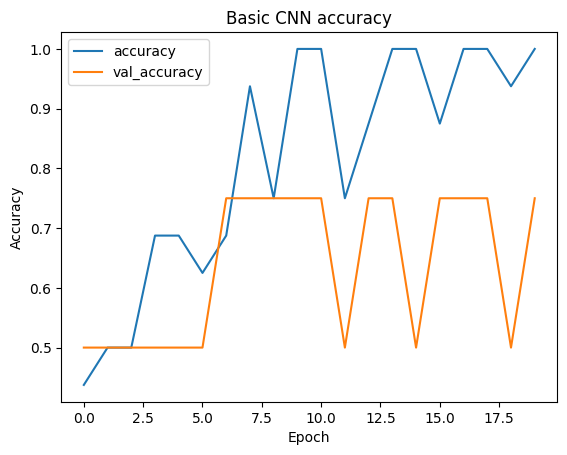

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
True and Predicted Classes:
Image norust/002_mjcgc4b1.ru0.jpg: True = 0, Predicted = 0
Image norust/002_ocpp5ini.zep.jpg: True = 0, Predicted = 1
Image rust/003_glbjresp.01k.jpg: True = 1, Predicted = 0
Image rust/004_z3jrhz45.3ms.jpg: True = 1, Predicted = 0


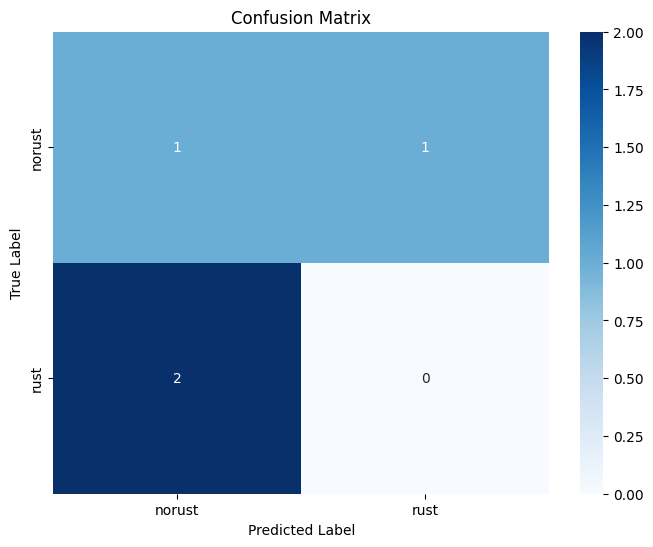

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7500 - loss: 0.5826
Test accuracy of Basic CNN: 75.00%
Saving Predicted CNN to /content/cnn_test
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


In [32]:
import os

cnn_model = with_basic_cnn(train_dir, test_dir)
# Ensure the directory exists before saving the model
os.makedirs(os.path.dirname(BASE_PATH + "/models/simple_cnn.keras"), exist_ok=True)
cnn_model.save(BASE_PATH + "/models/simple_cnn.keras")

ResNet 50

In [33]:
def with_resnet50(train_dir, test_dir):
  """
  Function to build, train and test the ResNet50 model
  :param train_dir: The directory of the training data
  :param test_dir: The directory of the testing data
  :return: model_builder
  """
  # Define target image's width and height
  image_width, image_height = 224, 224
  # Get the initial ResNet50 and freeze it
  initial_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(image_width, image_height, 3))
  initial_resnet50.trainable = False
  # Create a sequential builder for initial ResNet50 and add some more layers
  model_builder = Sequential([
      initial_resnet50,
      GlobalAveragePooling2D(),
      Dense(128, activation='relu'),
      Dense(2, activation='softmax')
  ])
  model_builder.summary()
  # Compile with adam and categorical crossentropy
  model_builder.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  # Convert train and test dataset using ImageDataGenerator
  train_datagen = ImageDataGenerator(rescale=1./255)
  test_datagen = ImageDataGenerator(rescale=1./255)

  train_generator = train_datagen.flow_from_directory(train_dir, target_size=(image_width, image_height), batch_size=32, class_mode='categorical')
  test_generator = test_datagen.flow_from_directory(test_dir, target_size=(image_width, image_height), batch_size=32, class_mode='categorical')
  print("Test generator: ", test_generator)
  # Fith with 20 epochs (100 steps per epoch)
  history = model_builder.fit(train_generator, epochs=20, steps_per_epoch=100, validation_data=test_generator, validation_steps=50)
  # Plot the accuracy
  plot_accuracy(history, "ResNet50")
  show_true_and_predicted_classes(model_builder, test_generator)
  # Eval and save predicted images to the folder
  print(f"Test accuracy of ResNet50: {model_builder.evaluate(test_generator)[1] * 100:.2f}%")
  print(f"Saving Predicted CNN to {BASE_PATH}/resnet50_test")
  save_predicted_images(model_builder, test_generator, BASE_PATH + "/resnet50_test")
  return model_builder

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Test generator:  <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7bc0beceaff0>
Epoch 1/20
  1/100 ━━━━━━━━━━━━━━━━━━━━ 21:59 13s/step - accuracy: 0.5000 - loss: 0.8440

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5000 - loss: 0.8440 - val_accuracy: 0.5000 - val_loss: 0.7050
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5000 - loss: 0.7074 - val_accuracy: 0.5000 - val_loss: 0.7819
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5000 - loss: 0.7862 - val_accuracy: 0.5000 - val_loss: 0.7460
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5000 - loss: 0.7489 - val_accuracy: 0.5000 - val_loss: 0.6972
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5000 - loss: 0.6970 - val_accuracy: 0.5000 - val_loss: 0.7027
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5000 - loss: 0.7008 - val_accuracy: 0.5000 - val_loss: 0.7317
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5000 - loss: 0.7290 - val_accuracy: 0.5000 - val_loss: 0.7347
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5000 - loss: 0.7313 - val_accuracy: 0.5000 -

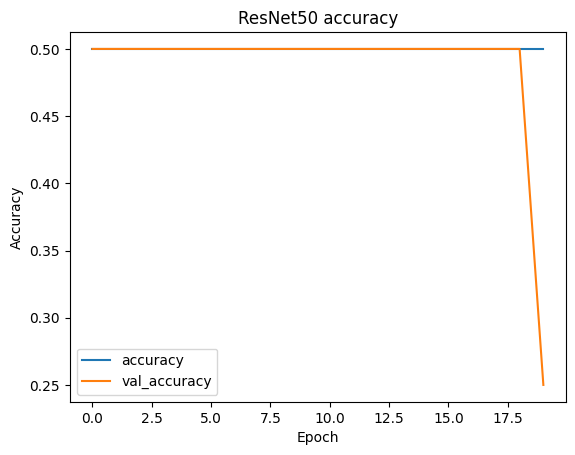

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
True and Predicted Classes:
Image norust/002_mjcgc4b1.ru0.jpg: True = 0, Predicted = 0
Image norust/002_ocpp5ini.zep.jpg: True = 0, Predicted = 0
Image rust/003_glbjresp.01k.jpg: True = 1, Predicted = 1
Image rust/004_z3jrhz45.3ms.jpg: True = 1, Predicted = 0


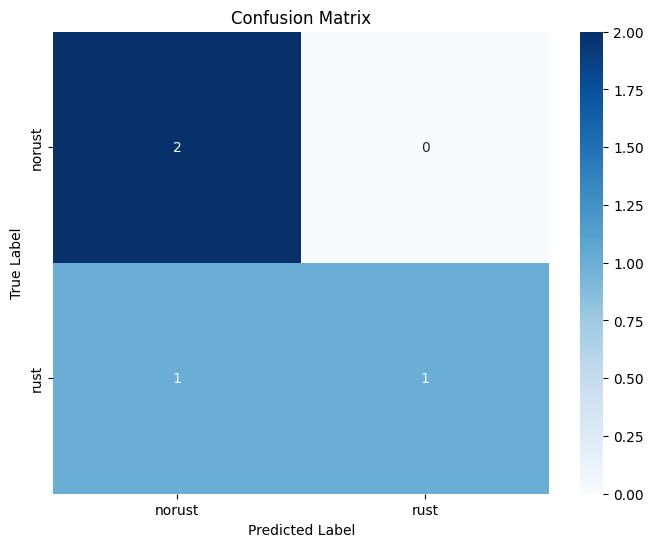

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - accuracy: 0.2500 - loss: 0.6956
Test accuracy of ResNet50: 25.00%
Saving Predicted CNN to /content/resnet50_test


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [34]:
resnet_model = with_resnet50(train_dir, test_dir)
resnet_model.save(BASE_PATH + "/models/resnet50.keras")